# Cycle phases via a hidden semi-Markov model (HSMM)

An alternative to the per-cycle change-point in `cycle_transition_model.ipynb`. Same goal —
locate the wearable **follicular→luteal biometric transition** — but framed as a **latent-state sequence
model**, which is what this problem actually is.

**States (ordered, per cycle):** `Menstruation → Follicular → Luteal`. Menstruation is
*observed* (the logged `is_period` days), so the only unknown is the single **Follicular→Luteal
boundary** = the estimated biometric luteal onset. External hormone validation suggests this boundary can trail the LH peak by a few days.

**Use case:** this is the modeling core for a wearable-based femtech / sports workflow: estimate when recovery, HRV, RHR, respiration, sleep, or symptoms should be interpreted in a luteal rather than follicular context. The boundary is a physiological signal transition, not a standalone clinical ovulation test.

**Retrospective caveat:** this notebook scores completed cycles. It uses the known next period date to constrain/regularize luteal length. A live implementation would instead update `P(transition has happened by today)` each day and keep uncertainty high until the cycle closes.

**Why semi-Markov, not a plain HMM.** In  standard HMM, the time that a point spends in a given state follows a geometric distribution, being the most likely duration is *1 day* — it cannot say "the luteal phase lasts about 13 days", so a plain Gaussian HMM here collapses (the luteal state starts as early
as allowed and swallows the follicular phase). A **semi-Markov** model attaches an explicit
**duration distribution** to the luteal state, which is exactly the structure we need.

**What we compute per cycle:**
- **MAP boundary** (the Viterbi analog): the single boundary maximizing the emission likelihood
  plus the luteal-duration prior.
- **Posterior over the boundary** (the forward–backward analog): a full distribution over the
  transition day → a per-cycle uncertainty / confidence, not just a point estimate.

**Emissions:** Each state is represented by a multivariate Gaussian distribution over RHR, sleep respiration, HRV, and sleep stress. This preserves information from the individual signals and their correlations, unlike the change-point model’s squared-error likelihood on a one-dimensional composite. The state-specific Gaussian parameters are initialized semi-supervised using approximate labels anchored to the observed menstruation days.


In [32]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the repo root importable (collection -> preprocessing -> analysis stay separate).
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "preprocessing").exists():
    REPO_ROOT = Path("/home/elsa/projects/garmin")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import importlib
import preprocessing.cycle_phases as cycle_phase_preprocessing
import preprocessing.outliers as outlier_preprocessing
importlib.reload(cycle_phase_preprocessing)
importlib.reload(outlier_preprocessing)
from preprocessing.cycle_phases import derive_cycle_phases
from preprocessing.outliers import flag_confounders, apply_confound_mask

DATA_FILE = Path("data/garmin_data_730days/garmin_data_730days.csv")
if not DATA_FILE.exists():
    DATA_FILE = REPO_ROOT / DATA_FILE

ANCHOR_DAYS = 6 # early follicular late luteal duration
SIGNALS = ["resting_hr", "avg_sleep_respiration", "hrv_rmssd", "avg_sleep_stress"]
D = len(SIGNALS)

df = pd.read_csv(DATA_FILE, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
if "is_period" not in df.columns:
    raise ValueError("Expected freshly fetched data with an `is_period` column.")
df = df.drop(columns=["cycle_phase"], errors="ignore")

# Preprocessing: same stages as the change-point notebook, so the two are comparable.
df = derive_cycle_phases(df, anchor_days=ANCHOR_DAYS)
df = flag_confounders(df)
df = apply_confound_mask(df, signals=SIGNALS)   # NaN confounded days; imputed below

# Cycle segmentation.
is_start = df["is_period"] & ~df["is_period"].shift(1, fill_value=False)
df["cycle_id"] = is_start.cumsum()
cstart = df.groupby("cycle_id")["date"].min()
nstart = cstart.shift(-1)
df["cycle_day"] = (df["date"] - df["cycle_id"].map(cstart)).dt.days
df["cycle_len"] = df["cycle_id"].map((nstart - cstart).dt.days)

n_cycles = df.loc[df["cycle_len"].notna(), "cycle_id"].nunique()
print("Shape:", df.shape, "| complete cycles:", n_cycles)
print("Median cycle length:", df.groupby("cycle_id")["cycle_len"].first().median())


Shape: (731, 61) | complete cycles: 26
Median cycle length: 28.0


## Emissions — one multivariate Gaussian per state

Signals are robust-standardized (median / MAD) across the whole record, then imputed so every
day has a complete observation vector, and each state gets a multivariate-Gaussian emission
seeded semi-supervised from labelled days.

- **Luteal** is seeded from the `Late luteal` anchors.
- **Follicular** is seeded from the **post-menstrual nadir** — the ~6 days *after* bleeding ends —
  rather than the shared `Early follicular` anchor. That anchor correctly counts the bleeding
  days as follicular, but menses carries transiently elevated RHR / suppressed HRV that blurs the
  follicular↔luteal contrast; and with a 6-day anchor overlapping a ~5-day period it leaves only
  ~1 non-period day per cycle to estimate from. Training on the post-menstrual days both populates
  the estimate and *sharpens* the contrast (empirically the best of the windows tried), and
  matches the days the segmenter actually scores. This is a **model-local** choice — the shared
  anchor in `preprocessing/cycle_phases.py` is left untouched, since it is also a classification
  target for `Pipeline-model.ipynb`.

The printed means are a physiological sanity check: Luteal should show **higher RHR, lower HRV,
higher sleep stress** than Follicular.


In [33]:
# Robust-standardize + impute -> observation matrix.
# median absolute deviation (MAD) is less sensitive to outliers
X = df[SIGNALS].interpolate(limit_direction="both").to_numpy(float)
med = np.median(X, 0)
mad = np.median(np.abs(X - med), 0) * 1.4826
mad[mad == 0] = 1.0
X = (X - med) / mad
for j, s in enumerate(SIGNALS):
    df[f"z_{s}"] = X[:, j]

is_period = df["is_period"].to_numpy(bool)
lab = df["cycle_phase"].to_numpy()

# Per-cycle end of menstruation (cycle_day of the first post-period day).
period_end = df.loc[is_period].groupby("cycle_id")["cycle_day"].max() + 1
df["period_end"] = df["cycle_id"].map(period_end)

def mvn_params(mask, reg=0.2):
    Xm = X[mask]
    return Xm.mean(0), np.cov(Xm.T) + reg * np.eye(D)

# Follicular emission: seed from the POST-menstrual nadir, not from period-start.
# The shared "Early follicular" anchor (in preprocessing) correctly counts the
# bleeding days as follicular, but menses carries transiently high RHR / suppressed
# HRV that blurs the follicular<->luteal contrast this model relies on -- and with a
# ~6-day anchor overlapping a ~5-day period it leaves only ~1 non-period day/cycle to
# estimate from. Training muF on the ~6 days AFTER menses ends (the follicular nadir)
# both populates the estimate and sharpens the contrast, and matches the days the
# segmenter actually scores. The `cycle_len - 16` guard keeps the window from spilling
# into early-luteal on short cycles. This is a model-local choice; the anchor is untouched.
cd = df["cycle_day"].to_numpy()
pe = df["period_end"].to_numpy()
foll_hi = np.minimum(pe + 6, df["cycle_len"].to_numpy() - 16)
foll_mask = (~is_period) & (cd >= pe) & (cd < foll_hi)

muF, SigF = mvn_params(foll_mask)
muL, SigL = mvn_params(lab == "Late luteal")

print(f"Follicular training days: {int(foll_mask.sum())}")
print("Follicular mean:", dict(zip(SIGNALS, muF.round(2))))
print("Luteal     mean:", dict(zip(SIGNALS, muL.round(2))))


Follicular training days: 133
Follicular mean: {'resting_hr': np.float64(-0.21), 'avg_sleep_respiration': np.float64(-0.36), 'hrv_rmssd': np.float64(0.22), 'avg_sleep_stress': np.float64(-0.34)}
Luteal     mean: {'resting_hr': np.float64(0.56), 'avg_sleep_respiration': np.float64(0.11), 'hrv_rmssd': np.float64(-0.43), 'avg_sleep_stress': np.float64(0.65)}


## The one-boundary HSMM

For each complete cycle, days split into `Menstruation` (the logged period days),
`Follicular`, and `Luteal`, in that order. Menstruation is known, so a single boundary `b`
(the first luteal day) defines the segmentation. We score every feasible `b` by

```
score(b) =  Σ_{t in Follicular} log N(x_t | μ_F, Σ_F)
          + Σ_{t in Luteal}     log N(x_t | μ_L, Σ_L)
          + log P_dur(luteal length = cycle_len − b)      # semi-Markov duration prior
```

- **MAP boundary** = `argmax_b score(b)` (Viterbi analog).
- **Posterior** `P(b) ∝ exp(score(b))`, normalized over feasible `b` (forward–backward analog)
  → a distribution over the biometric transition day, giving `transition_expected` and a `confidence`
  (posterior peak).

The feasible range for `b` reuses the change-point notebook's physiological window
(`period_end + 4` … `cycle_len − 4`, capped at `MAX_LUT`), so the two methods are compared on
equal footing. The duration prior is **soft** (`DUR_SD = 2.5`): as the next cell shows,
emissions alone already place the median luteal length near 13, so the prior *regularizes* noisy
cycles rather than dictating the answer. The boundary is interpreted as wearable luteal onset,
not exact LH-peak ovulation.


In [34]:
MIN_AFTER, MIN_LUT, MAX_LUT = 4, 4, 19   # physiological boundary window (mirrors cycle_transition_model)
DUR_MU, DUR_SD = 13.0, 2.5               # soft prior on luteal length only, not on both states
LH_PEAK_LAG_DAYS = 3.5                    # mcPHASES pooled median: transition - LH peak


def logmvn(Xm, mu, Sig):
    Lc = np.linalg.cholesky(Sig)
    logdet = 2 * np.sum(np.log(np.diag(Lc)))
    sol = np.linalg.solve(Lc, (Xm - mu).T)
    return -0.5 * (D * np.log(2 * np.pi) + logdet + np.sum(sol ** 2, 0))


def segment_cycle(gc, use_duration=True):
    """One-boundary HSMM for a single cycle. Returns MAP boundary + boundary posterior."""
    gc = gc.sort_values("cycle_day")
    cl = int(gc["cycle_len"].iloc[0])
    cd = gc["cycle_day"].to_numpy()
    ipc = gc["is_period"].to_numpy(bool)
    Xc = gc[[f"z_{s}" for s in SIGNALS]].to_numpy()
    p_end = int(cd[ipc].max()) + 1

    lF = logmvn(Xc, muF, SigF)
    lL = logmvn(Xc, muL, SigL)

    c0 = max(p_end + MIN_AFTER, cl - MAX_LUT)
    c1 = cl - MIN_LUT
    cands = np.arange(c0, c1 + 1)
    scores = np.empty(len(cands), float)
    for i, b in enumerate(cands):
        in_f = (~ipc) & (cd >= p_end) & (cd < b)
        in_l = (~ipc) & (cd >= b)
        s = lF[in_f].sum() + lL[in_l].sum()
        if use_duration:
            s += -0.5 * ((cl - b - DUR_MU) / DUR_SD) ** 2   # log prior for luteal_len = cycle_len - b
        scores[i] = s

    post = np.exp(scores - scores.max())
    post /= post.sum()
    b_map = int(cands[np.argmax(scores)])
    return {"cands": cands, "post": post, "cycle_len": cl,
            "transition_day": b_map, "transition_expected": float((post * cands).sum()),
            "lh_peak_proxy_day": b_map - LH_PEAK_LAG_DAYS,
            "ovul_map": b_map, "ovul_expected": float((post * cands).sum()),  # backward-compatible aliases
            "confidence": float(post.max())}


In [35]:
def collect(use_duration):
    rows = []
    for cid, gc in df[df["cycle_len"].notna()].groupby("cycle_id"):
        fert = gc.loc[gc["garmin_predicted_fertile"] == True, "cycle_day"]   # noqa: E712
        if fert.empty:
            continue
        r = segment_cycle(gc, use_duration)
        garmin_ov = int(fert.max()) - 2      # Garmin rule: ovulation proxy = fertile-window end - 2
        rows.append({
            "cycle_id": cid, "cycle_len": r["cycle_len"],
            "transition_day": r["transition_day"],
            "transition_expected": round(r["transition_expected"], 1),
            "lh_peak_proxy_day": round(r["lh_peak_proxy_day"], 1),
            "confidence": round(r["confidence"], 2),
            "luteal_len": r["cycle_len"] - r["transition_day"],
            "garmin_ov_day": garmin_ov,
            "transition_minus_garmin_ov": r["transition_day"] - garmin_ov,
            "lh_proxy_minus_garmin_ov": r["lh_peak_proxy_day"] - garmin_ov,
        })
    return pd.DataFrame(rows).sort_values("cycle_id").reset_index(drop=True)


transitions_hsmm = collect(use_duration=True)
emissions_only = collect(use_duration=False)


def summarize(R):
    o = R["transition_minus_garmin_ov"]
    return {"n": len(R), "median_luteal": R["luteal_len"].median(),
            "std_luteal": round(R["luteal_len"].std(), 1),
            "median_offset": o.median(), "offset_MAD": round((o - o.median()).abs().median(), 1),
            "within_2d_%": round((o.abs() <= 2).mean() * 100)}

print("Emissions only (no duration prior):", summarize(emissions_only))
print("Emissions + luteal-duration prior :", summarize(transitions_hsmm))
print("Change-point baseline (other nb)  : median_luteal ~12, offset_MAD ~2.0-2.5, within_2d ~50%")
print("\noffset = HSMM biometric transition - Garmin ovulation proxy (fertile-end - 2)")
print(f"optional LH-peak proxy = transition - {LH_PEAK_LAG_DAYS} days; use as a secondary approximation")
transitions_hsmm


Emissions only (no duration prior): {'n': 26, 'median_luteal': np.float64(11.0), 'std_luteal': np.float64(4.7), 'median_offset': np.float64(2.0), 'offset_MAD': np.float64(3.5), 'within_2d_%': 31}
Emissions + luteal-duration prior : {'n': 26, 'median_luteal': np.float64(13.0), 'std_luteal': np.float64(3.0), 'median_offset': np.float64(0.0), 'offset_MAD': np.float64(2.0), 'within_2d_%': 65}
Change-point baseline (other nb)  : median_luteal ~12, offset_MAD ~2.0-2.5, within_2d ~50%

offset = HSMM biometric transition - Garmin ovulation proxy (fertile-end - 2)
optional LH-peak proxy = transition - 3.5 days; use as a secondary approximation


,cycle_id,cycle_len,transition_day,transition_expected,lh_peak_proxy_day,confidence,luteal_len,garmin_ov_day,transition_minus_garmin_ov,lh_proxy_minus_garmin_ov
0,1,24,13,13.8,9.5,0.21,11,11,2,-1.5
1,2,24,13,12.1,9.5,0.27,11,11,2,-1.5
2,3,25,12,12.8,8.5,0.24,13,12,0,-3.5
3,4,25,12,12.2,8.5,0.28,13,12,0,-3.5
4,5,25,14,13.3,10.5,0.20,11,12,2,-1.5
5,6,23,10,10.4,6.5,0.36,13,10,0,-3.5
6,7,31,19,18.8,15.5,0.40,12,18,1,-2.5
7,8,25,17,17.5,13.5,0.37,8,12,5,1.5
8,9,25,14,14.7,10.5,0.25,11,12,2,-1.5
9,10,31,25,24.5,21.5,0.28,6,18,7,3.5


## Diagnostics

Left: the duration prior tightens the luteal-length distribution (the regularizing effect).
Right: how far the HSMM **biometric transition** sits from Garmin's ovulation proxy.
The optional LH-peak proxy is the transition shifted earlier by the mcPHASES median lag; it
should be treated as a secondary approximation, not the primary model output.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
# fig.set_facecolor("white")

bins = np.arange(4.5, 21.6, 1)
axes[0].hist(emissions_only["luteal_len"], bins=bins, alpha=0.5, color="#999999",
             edgecolor="white", label=f"emissions only (std {emissions_only['luteal_len'].std():.1f})")
axes[0].hist(transitions_hsmm["luteal_len"], bins=bins, alpha=0.7, color="#4c72b0",
             edgecolor="white", label=f"+ duration prior (std {transitions_hsmm['luteal_len'].std():.1f})")
axes[0].axvline(DUR_MU, color="#333", ls="--", lw=1, label=f"prior mean {DUR_MU:.0f}d")
axes[0].set_xlabel("luteal length (days)")
axes[0].set_ylabel("cycles")
axes[0].set_title("Luteal-length distribution")
axes[0].legend(frameon=False, fontsize=8)

o = transitions_hsmm["transition_minus_garmin_ov"]
axes[1].hist(o, bins=np.arange(-6.5, 7.6, 1), color="#dd8452", edgecolor="white")
axes[1].axvline(0, color="#333", ls="--", lw=1)
axes[1].axvspan(-2, 2, color="#4c72b0", alpha=0.10, label="within 2 d")
axes[1].set_xlabel("HSMM transition - Garmin ovulation proxy (days)")
axes[1].set_ylabel("cycles")
axes[1].set_title(f"Biometric transition offset vs Garmin rule (median {o.median():+.0f} d, "
                  f"within 2 d: {(o.abs() <= 2).mean() * 100:.0f}%)")
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()


In [ ]:
# Boundary posteriors for a sample of cycles: where is the biometric transition, and how sure are we?
sample = transitions_hsmm["cycle_id"].head(9).tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 9), sharey=True)
# fig.set_facecolor("white")
by_id = dict(tuple(df[df["cycle_len"].notna()].groupby("cycle_id")))

for ax, cid in zip(axes.ravel(), sample):
    r = segment_cycle(by_id[cid], use_duration=True)
    ax.bar(r["cands"], r["post"], color="#4c72b0", width=0.9)
    ax.axvline(r["transition_day"], color="#c44e52", lw=1.5, label=f"transition day {r['transition_day']}")
    ax.axvline(r["lh_peak_proxy_day"], color="#7b3294", ls=":", lw=1.2, label="LH-peak proxy")
    grow = df.loc[(df["cycle_id"] == cid) & (df["garmin_predicted_fertile"] == True), "cycle_day"]
    if not grow.empty:
        ax.axvline(int(grow.max()) - 2, color="#55a868", ls="--", lw=1.5, label="Garmin ov proxy")
    ax.set_title(f"cycle {cid} (len {r['cycle_len']})", fontsize=9)
    ax.legend(frameon=False, fontsize=7)
    ax.set_xlabel("cycle day")
axes[0, 0].set_ylabel("P(transition = day)")
axes[1, 0].set_ylabel("P(transition = day)")
fig.suptitle("Per-cycle biometric-transition posterior (peaked = confident, flat = uncertain)")
fig.tight_layout()
plt.show()


## Visual audit — HSMM transition calculation

For each cycle, this plot shows the two pieces that drive the HSMM boundary estimate:

- the line is the per-day emission evidence, `log p(x | Luteal) - log p(x | Follicular)`. Values above zero mean the day looks more luteal than follicular under the Gaussian emissions.
- the blue bars are the normalized posterior over candidate transition days, after adding the optional luteal-duration prior. The red line is the MAP boundary.

This mirrors the `P(luteal)` audit plot: instead of a probability curve crossing 0.5, the HSMM chooses the boundary with the best total before/after emission likelihood plus the duration prior.


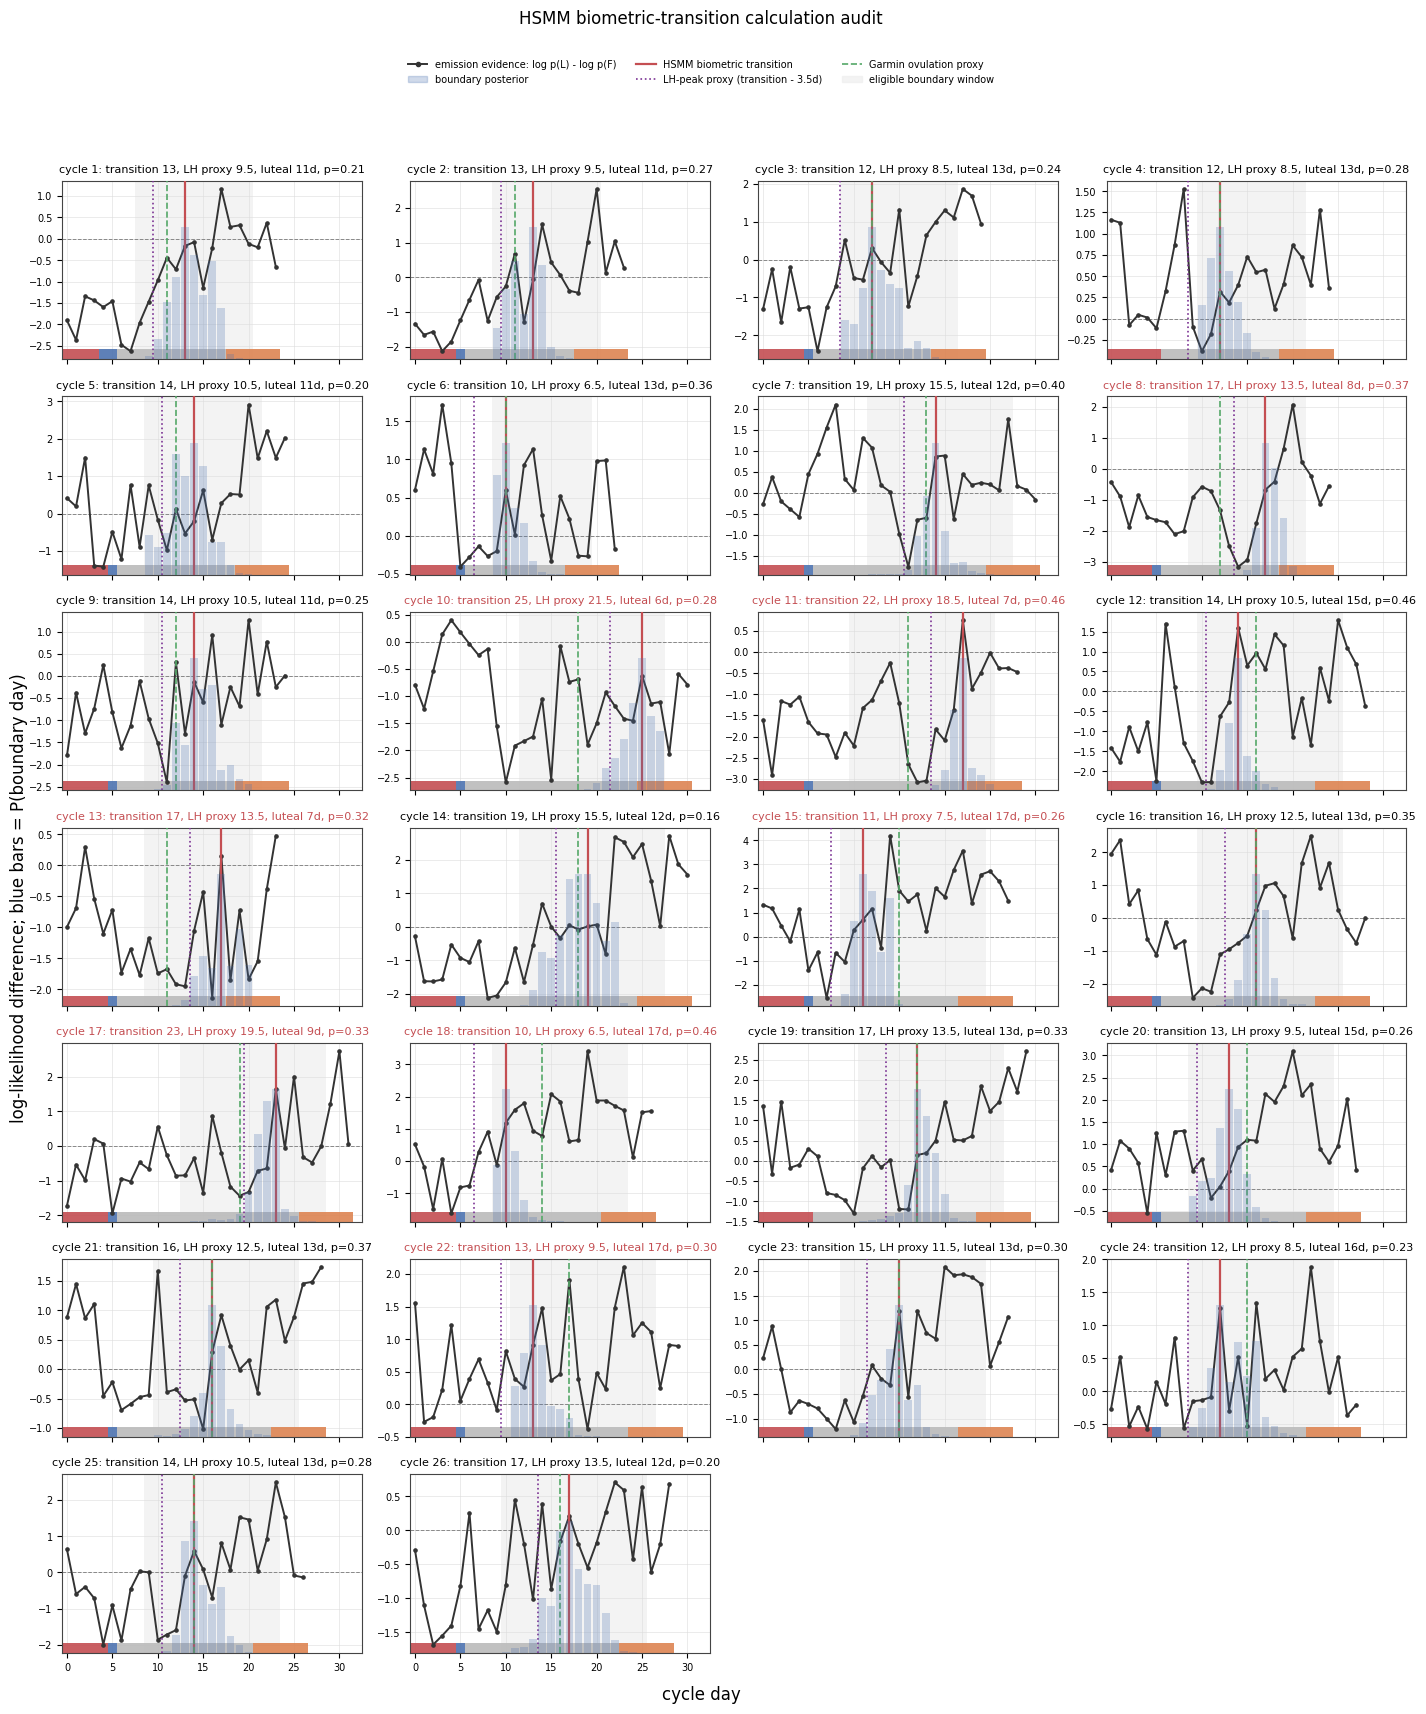

In [44]:
# Per-cycle HSMM transition audit: emission evidence + boundary posterior.
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

plt.style.use("default")


def style_light_axis(ax, grid=True):
    """Make plots readable even when Jupyter itself is in dark mode."""
    ax.set_facecolor("white")
    ax.tick_params(axis="both", colors="black", labelcolor="black", labelsize=7)
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    for spine in ax.spines.values():
        spine.set_color("#444444")
    if grid:
        ax.grid(True, color="#dddddd", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)


def hsmm_boundary_details(gc, use_duration=True):
    """Return per-day emission evidence and per-boundary posterior for one cycle."""
    gc = gc.sort_values("cycle_day").copy()
    cl = int(gc["cycle_len"].iloc[0])
    cd = gc["cycle_day"].to_numpy()
    ipc = gc["is_period"].to_numpy(bool)
    Xc = gc[[f"z_{s}" for s in SIGNALS]].to_numpy()
    p_end = int(cd[ipc].max()) + 1

    lF = logmvn(Xc, muF, SigF)
    lL = logmvn(Xc, muL, SigL)
    llr = lL - lF  # positive = day is more luteal-like than follicular-like

    c0 = max(p_end + MIN_AFTER, cl - MAX_LUT)
    c1 = cl - MIN_LUT
    cands = np.arange(c0, c1 + 1)
    scores = np.empty(len(cands), float)
    emission_scores = np.empty(len(cands), float)
    duration_scores = np.zeros(len(cands), float)

    for i, b in enumerate(cands):
        in_f = (~ipc) & (cd >= p_end) & (cd < b)
        in_l = (~ipc) & (cd >= b)
        emission_score = lF[in_f].sum() + lL[in_l].sum()
        duration_score = 0.0
        if use_duration:
            duration_score = -0.5 * ((cl - b - DUR_MU) / DUR_SD) ** 2
        emission_scores[i] = emission_score
        duration_scores[i] = duration_score
        scores[i] = emission_score + duration_score

    post = np.exp(scores - scores.max())
    post /= post.sum()
    b_map = int(cands[np.argmax(scores)])
    lh_peak_proxy = b_map - LH_PEAK_LAG_DAYS

    day_scores = gc[["date", "cycle_id", "cycle_day", "cycle_phase", "is_period"]].copy()
    day_scores["llr_luteal_minus_follicular"] = llr
    cand_scores = pd.DataFrame({
        "cycle_day": cands,
        "posterior": post,
        "score": scores,
        "emission_score": emission_scores,
        "duration_score": duration_scores,
        "luteal_len": cl - cands,
    })
    return day_scores, cand_scores, b_map, lh_peak_proxy, cl, p_end


PHASE_COLORS = {"Period": "#c44e52", "Early follicular": "#4c72b0",
                "Not logged": "#bbbbbb", "Late luteal": "#dd8452"}
by_id = dict(tuple(df[df["cycle_len"].notna()].groupby("cycle_id")))
cyc_ids = transitions_hsmm["cycle_id"].tolist()

ncol = 4
nrow = int(np.ceil(len(cyc_ids) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 2.35 * nrow), sharex=True, squeeze=False)
fig.set_facecolor("white")
fig.patch.set_alpha(1.0)

for ax, cid in zip(axes.flat, cyc_ids):
    day_scores, cand_scores, b_map, lh_peak_proxy, cl, p_end = hsmm_boundary_details(by_id[cid], use_duration=True)
    tr = transitions_hsmm.loc[transitions_hsmm["cycle_id"] == cid].iloc[0]

    style_light_axis(ax)
    ax.axhline(0, color="#888888", ls="--", lw=0.7, zorder=1)
    ax.axvspan(cand_scores["cycle_day"].min() - 0.5,
               cand_scores["cycle_day"].max() + 0.5,
               color="#eeeeee", alpha=0.7, linewidth=0, zorder=0)

    # Emission evidence: positive days look more luteal-like under the Gaussian emissions.
    ax.plot(day_scores["cycle_day"], day_scores["llr_luteal_minus_follicular"],
            color="#333333", lw=1.4, marker="o", ms=2.3, zorder=3)

    # Boundary posterior on a secondary axis so uncertainty is visible without hiding the evidence line.
    ax2 = ax.twinx()
    ax2.patch.set_alpha(0.0)
    ax2.set_zorder(ax.get_zorder() + 1)
    ax.patch.set_visible(True)
    ax2.bar(cand_scores["cycle_day"], cand_scores["posterior"], width=0.85,
            color="#4c72b0", alpha=0.26, linewidth=0, zorder=2)
    ax2.set_ylim(0, max(0.05, cand_scores["posterior"].max() * 1.35))
    ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)

    ax.axvline(b_map, color="#c44e52", lw=1.6, zorder=4)
    ax.axvline(lh_peak_proxy, color="#7b3294", ls=":", lw=1.2, zorder=4)
    grow = by_id[cid].loc[by_id[cid]["garmin_predicted_fertile"] == True, "cycle_day"]  # noqa: E712
    if not grow.empty:
        ax.axvline(int(grow.max()) - 2, color="#55a868", ls="--", lw=1.2, zorder=4)

    for _, r in day_scores.iterrows():
        phase_key = "Period" if r.get("is_period", False) else r["cycle_phase"]
        ax.axvspan(r["cycle_day"] - 0.5, r["cycle_day"] + 0.5,
                   ymin=0, ymax=0.055,
                   color=PHASE_COLORS.get(phase_key, "#cccccc"),
                   alpha=0.9, linewidth=0, zorder=1)

    title_color = "#c44e52" if not (10 <= tr["luteal_len"] <= 16) else "black"
    ax.set_title(f"cycle {cid}: transition {b_map}, LH proxy {lh_peak_proxy:.1f}, luteal {int(tr['luteal_len'])}d, p={tr['confidence']:.2f}",
                 fontsize=8, color=title_color)
    ax.set_xlim(-0.5, max(32.5, day_scores["cycle_day"].max() + 0.5))

for ax in axes.flat[len(cyc_ids):]:
    ax.set_facecolor("white")
    ax.axis("off")

legend_handles = [
    Line2D([0], [0], color="#333333", marker="o", ms=3, lw=1.4,
           label="emission evidence: log p(L) - log p(F)"),
    mpatches.Patch(color="#4c72b0", alpha=0.26, label="boundary posterior"),
    Line2D([0], [0], color="#c44e52", lw=1.6, label="HSMM biometric transition"),
    Line2D([0], [0], color="#7b3294", lw=1.2, ls=":", label=f"LH-peak proxy (transition - {LH_PEAK_LAG_DAYS}d)"),
    Line2D([0], [0], color="#55a868", lw=1.2, ls="--", label="Garmin ovulation proxy"),
    mpatches.Patch(color="#eeeeee", alpha=0.7, label="eligible boundary window"),
]
legend = fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False,
                    bbox_to_anchor=(0.5, 1.015), fontsize=7)
for text in legend.get_texts():
    text.set_color("black")
fig.supxlabel("cycle day", color="black")
fig.supylabel("log-likelihood difference; blue bars = P(boundary day)", color="black")
fig.suptitle("HSMM biometric-transition calculation audit", y=1.04, color="black")
fig.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()


In [ ]:
# Decoded phases over a stretch of the record, with RHR overlaid.
bmap = {cid: segment_cycle(gc, True)["transition_day"]
        for cid, gc in df[df["cycle_len"].notna()].groupby("cycle_id")}

def day_phase(row):
    if row["is_period"]:
        return "Menstruation"
    b = bmap.get(row["cycle_id"])
    if b is None or pd.isna(row["cycle_len"]):
        return "Not scored"
    return "Luteal" if row["cycle_day"] >= b else "Follicular"

df["hsmm_phase"] = df.apply(day_phase, axis=1)

PHASE_COLORS = {"Menstruation": "#c44e52", "Follicular": "#4c72b0", "Luteal": "#dd8452"}
window = df[df["date"] < df["date"].min() + pd.Timedelta(days=140)]

fig, ax = plt.subplots(figsize=(14, 4))
# fig.set_facecolor("white")
for _, r in window.iterrows():
    c = PHASE_COLORS.get(r["hsmm_phase"])
    if c:
        ax.axvspan(r["date"], r["date"] + pd.Timedelta(days=1), color=c, alpha=0.30)
ax.plot(window["date"], window["resting_hr"], color="darkred", marker="o", ms=3, lw=1.2)
ax.set_ylabel("Resting HR (bpm)")
ax.set_title("HSMM-decoded biometric phases vs resting HR (first ~140 days)")
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=c, alpha=0.3, label=p) for p, c in PHASE_COLORS.items()],
          loc="upper left", ncol=3, fontsize=8)
fig.tight_layout()
plt.show()


## Results & next steps

On this single-person record the HSMM matches or slightly beats the change-point baseline
(tighter luteal spread, offset centered on 0, higher within-2-day agreement with Garmin), and
it adds a **per-cycle uncertainty** the change-point never gave.

Where to take it:

1. **Validate against hormonal truth (mcPHASES).** The Garmin offset is agreement with another
   *algorithm*. The PhysioNet mcPHASES dataset has LH/E3G/PdG-labeled ovulation — the real test,
   and enough people to fit the emissions properly.
2. **Add temperature.** Wrist/skin temperature is the strongest ovulation marker in the
   literature and is absent here; adding it (if the device logs it) is likely a bigger gain than
   any model tweak.
3. **Discriminative emissions (hybrid).** Replace the Gaussian emissions with a calibrated
   classifier's per-day `P(luteal | features)` inside the same HSMM — the best published
   4-phase models do exactly this.
4. **A 4th `Ovulation` state.** Only identifiable with a sharper signal (temperature / hormones);
   revisit after 1–2.
